# ⚙️ Feature Engineering & Modelado — Predicción de Churn
### Arca Continental · Canal Tradicional México 2024
---
**Prerrequisito:** haber ejecutado el notebook `EDA_Maestro_Churn.ipynb`.  
Los CSV fuente deben estar en el mismo directorio de trabajo.

**Estructura del notebook:**
1. Importaciones y configuración global
2. Carga y merge de datos
3. Feature engineering — variables temporales
   - 3a. Lags (1, 2, 3 meses)
   - 3b. Medias y sumas rodantes (3 m y 6 m)
   - 3c. Desviación estándar rodante
   - 3d. Deltas (cambio absoluto)
   - 3e. Ratios (cambio relativo)
   - 3f. Meses activos y ratio de actividad
   - 3g. Coeficiente de variación (CV)
   - 3h. Z-score rodante
   - 3i. Máximo histórico rodante y ratio vs máximo
   - 3j. Recency: meses desde última compra
4. Exploración del dataset con features
5. Filtrado de registros para modelado
6. Modelado con CatBoost
   - 6a. Entrenamiento base (todas las features)
   - 6b. Entrenamiento con top-20 features
   - 6c. Optimización de hiperparámetros (Optuna)
   - 6d. Modelo final con hiperparámetros óptimos
7. Búsqueda del threshold óptimo
8. Importancia de variables (gráfica)
9. Persistencia del modelo
10. Predicción sobre datos de test (snapshot)


## 1. Importaciones y configuración global

In [1]:
# ──────────────────────────────────────────────────────────────
# IMPORTACIONES Y CONFIGURACIÓN GLOBAL
# Se reutiliza el mismo estilo visual del EDA maestro para
# mantener coherencia en todas las gráficas del proyecto.
# ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy.stats import linregress

# ── Estilo unificado (idéntico al EDA maestro) ────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f9f9f9',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.titleweight'  : 'bold',
})

# Paleta de colores consistente con el EDA maestro
COLOR_NO_CHURN = '#4CAF50'   # verde  → cliente retenido (target = 0)
COLOR_CHURN    = '#F44336'   # rojo   → cliente que abandona (target = 1)
COLOR_NEUTRAL  = '#42A5F5'   # azul   → datos sin comparación binaria
COLOR_WARN     = '#FF9800'   # naranja → énfasis secundario


## 2. Carga y merge de datos

In [2]:
# ──────────────────────────────────────────────────────────────
# CARGA DE LOS CSV FUENTE
# Se leen los mismos archivos que en el EDA maestro.
# ──────────────────────────────────────────────────────────────
clientes = pd.read_csv('Clientes.csv')
coolers  = pd.read_csv('Coolers.csv')
train    = pd.read_csv('Sales_churn_train.csv')

print(f"clientes : {clientes.shape[0]:,} filas × {clientes.shape[1]} columnas")
print(f"coolers  : {coolers.shape[0]:,} filas × {coolers.shape[1]} columnas")
print(f"train    : {train.shape[0]:,} filas × {train.shape[1]} columnas")


clientes : 371,727 filas × 4 columnas
coolers  : 4,636,676 filas × 4 columnas
train    : 5,030,534 filas × 5 columnas


In [3]:
# ──────────────────────────────────────────────────────────────
# MERGE MENSUAL (igual que en el EDA maestro)
# Se unen los tres datasets para tener toda la información
# disponible en un solo DataFrame de trabajo.
# ──────────────────────────────────────────────────────────────

# 1. Unir ventas con coolers usando customer_id + calmonth
data = pd.merge(train, coolers, on=['customer_id', 'calmonth'], how='left')

# 2. Agregar los atributos estáticos del cliente
data = pd.merge(data, clientes, on='customer_id', how='left')

print(f"Dataset integrado: {data.shape[0]:,} filas × {data.shape[1]} columnas")
data.head()


Dataset integrado: 5,032,039 filas × 10 columnas


,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target,num_coolers,num_doors,territory_d,comercial_subchannel_d,rtm_customer_size_d
0,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202410,29,65.166068,0,1.0,1.0,Saltillo,Hogares,Mini
1,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202411,25,56.640400,0,1.0,1.0,Saltillo,Hogares,Mini
2,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202412,10,21.486900,0,1.0,1.0,Saltillo,Hogares,Mini
3,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202501,11,21.698000,0,1.0,1.0,Saltillo,Hogares,Mini
4,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202502,17,33.709400,0,1.0,1.0,Saltillo,Hogares,Mini


## 3. Feature engineering — variables temporales

Las nuevas variables se calculan **dentro de cada cliente** (`groupby customer_id`) y
siempre usando **datos pasados** (`shift(1)` antes del rolling) para evitar *data leakage*
al momento de predecir.

Las variables base son `num_transacciones` y `uni_boxes_sold_m`.


In [4]:
# ──────────────────────────────────────────────────────────────
# PREPARACIÓN DEL DATAFRAME DE TRABAJO
# Se ordena por cliente y mes para que todas las operaciones
# de ventana temporal queden alineadas correctamente.
# ──────────────────────────────────────────────────────────────
df = data.copy()
df = df.sort_values(['customer_id', 'calmonth']).reset_index(drop=True)

# Variables sobre las que se construirán todos los features temporales
variables = ['num_transacciones', 'uni_boxes_sold_m']

print(f"Registros ordenados: {len(df):,}")
print(f"Rango temporal: {df['calmonth'].min()} → {df['calmonth'].max()}")


Registros ordenados: 5,032,039
Rango temporal: 202401 → 202601


### 3a. Lags — valores del mes anterior (1, 2 y 3 meses)

In [5]:
# ──────────────────────────────────────────────────────────────
# LAGS (1, 2 y 3 MESES)
# Un lag captura el valor observado N meses atrás para el mismo
# cliente. Son útiles para que el modelo "recuerde" el historial
# reciente de compra sin ver el mes actual.
# Ejemplo: num_transacciones_lag_1 = transacciones del mes pasado.
# ──────────────────────────────────────────────────────────────
for var in variables:
    for lag in [1, 2, 3]:
        df[f'{var}_lag_{lag}'] = (
            df.groupby('customer_id')[var]
              .shift(lag)   # desplaza N posiciones hacia adelante en el tiempo
        )

# Verificación: las primeras filas de cada cliente quedan como NaN (esperado)
print("Features de lag creados:")
lag_cols = [c for c in df.columns if '_lag_' in c]
print(lag_cols)


Features de lag creados:
['num_transacciones_lag_1', 'num_transacciones_lag_2', 'num_transacciones_lag_3', 'uni_boxes_sold_m_lag_1', 'uni_boxes_sold_m_lag_2', 'uni_boxes_sold_m_lag_3']


### 3b. Medias y sumas rodantes (3 m y 6 m)

In [6]:
# ──────────────────────────────────────────────────────────────
# MEDIAS Y SUMAS RODANTES — VENTANAS DE 3 Y 6 MESES
# Capturan el comportamiento promedio y el volumen acumulado
# reciente. Se aplica shift(1) ANTES del rolling para que el
# cálculo use únicamente meses anteriores (no el mes actual).
# min_periods=1 permite calcular aunque haya pocos meses de historia.
# ──────────────────────────────────────────────────────────────
for var in variables:

    # Media de los últimos 3 y 6 meses (excluyendo el mes actual)
    df[f'{var}_mean_3m'] = (
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )
    df[f'{var}_mean_6m'] = (
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    )

    # Suma acumulada de los últimos 3 y 6 meses
    df[f'{var}_sum_3m'] = (
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
    )
    df[f'{var}_sum_6m'] = (
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(6, min_periods=1).sum())
    )

print("Features de media/suma rodante creados:")
roll_cols = [c for c in df.columns if '_mean_' in c or '_sum_' in c]
print(roll_cols)


Features de media/suma rodante creados:
['num_transacciones_mean_3m', 'num_transacciones_mean_6m', 'num_transacciones_sum_3m', 'num_transacciones_sum_6m', 'uni_boxes_sold_m_mean_3m', 'uni_boxes_sold_m_mean_6m', 'uni_boxes_sold_m_sum_3m', 'uni_boxes_sold_m_sum_6m']


### 3c. Desviación estándar rodante (3 m y 6 m)

In [7]:
# ──────────────────────────────────────────────────────────────
# DESVIACIÓN ESTÁNDAR RODANTE — VENTANAS DE 3 Y 6 MESES
# Mide la volatilidad del comportamiento de compra del cliente.
# Un cliente muy irregular (std alta) puede ser más propenso
# al churn. min_periods=2 porque std necesita al menos 2 puntos.
# ──────────────────────────────────────────────────────────────
for var in variables:

    df[f'{var}_std_3m'] = (
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(3, min_periods=2).std())
    )
    df[f'{var}_std_6m'] = (
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(6, min_periods=2).std())
    )

print("Features de desviación estándar rodante creados:")
std_cols = [c for c in df.columns if '_std_' in c]
print(std_cols)


Features de desviación estándar rodante creados:
['num_transacciones_std_3m', 'num_transacciones_std_6m', 'uni_boxes_sold_m_std_3m', 'uni_boxes_sold_m_std_6m']


### 3d. Deltas — cambio absoluto respecto al pasado

In [8]:
# ──────────────────────────────────────────────────────────────
# DELTAS — CAMBIO ABSOLUTO MES A MES Y RESPECTO A MEDIA 3M
# delta_1m: diferencia entre el mes actual y el mes anterior.
# delta_3m: diferencia entre el mes actual y la media de los 3 meses previos.
# Valores negativos indican caída en actividad → señal de riesgo.
# ──────────────────────────────────────────────────────────────
for var in variables:

    # Cambio respecto al mes inmediatamente anterior
    df[f'{var}_delta_1m'] = df.groupby('customer_id')[var].diff(1)

    # Cambio respecto al promedio de los 3 meses previos
    df[f'{var}_delta_3m'] = (
        df[var] -
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

print("Features de delta creados:")
delta_cols = [c for c in df.columns if '_delta_' in c]
print(delta_cols)


Features de delta creados:
['num_transacciones_delta_1m', 'num_transacciones_delta_3m', 'uni_boxes_sold_m_delta_1m', 'uni_boxes_sold_m_delta_3m']


### 3e. Ratios — cambio relativo respecto al pasado

In [9]:
# ──────────────────────────────────────────────────────────────
# RATIOS — CAMBIO RELATIVO
# ratio_1m: valor actual / valor del mes anterior.
# ratio_3m: valor actual / media de los 3 meses previos.
# Se agrega eps (1e-6) al denominador para evitar división por cero.
# ratio > 1 → crecimiento; ratio < 1 → caída; ratio ≈ 0 → inactividad.
# ──────────────────────────────────────────────────────────────
EPS = 1e-6

for var in variables:

    lag1  = df.groupby('customer_id')[var].shift(1)
    mean3 = df.groupby('customer_id')[var].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )

    df[f'{var}_ratio_1m'] = df[var] / (lag1  + EPS)
    df[f'{var}_ratio_3m'] = df[var] / (mean3 + EPS)

print("Features de ratio creados:")
ratio_cols = [c for c in df.columns if '_ratio_1m' in c or '_ratio_3m' in c]
print(ratio_cols)


Features de ratio creados:
['num_transacciones_ratio_1m', 'num_transacciones_ratio_3m', 'uni_boxes_sold_m_ratio_1m', 'uni_boxes_sold_m_ratio_3m']


### 3f. Meses activos y ratio de actividad (ventana 6 m)

In [10]:
# ──────────────────────────────────────────────────────────────
# MESES ACTIVOS EN VENTANA DE 6 MESES
# Cuenta cuántos de los últimos 6 meses el cliente tuvo
# al menos 1 transacción. Un cliente que compra solo 1 de 6
# meses es muy distinto a uno que compra los 6.
# ──────────────────────────────────────────────────────────────
for var in variables:
    df[f'{var}_active_months_6m'] = (
        df.groupby('customer_id')[var]
          .transform(
              lambda x: x.shift(1).rolling(6, min_periods=1)
                         .apply(lambda y: (y > 0).sum())
          )
    )

# ──────────────────────────────────────────────────────────────
# HISTORIAL ACUMULADO DE MESES (contador desde el inicio)
# Se usa como denominador en el ratio de actividad para
# normalizar correctamente a clientes nuevos vs antiguos.
# ──────────────────────────────────────────────────────────────
df['hist_months'] = (
    df.groupby('customer_id')['calmonth']
      .transform(lambda x: (x != 0).cumsum())
)

# Ratio de actividad: meses activos / min(hist_months-1, 6)
# Evita sobre-penalizar a clientes nuevos con pocos meses de historia.
for var in variables:
    df[f'{var}_active_ratio_6m'] = (
        df[f'{var}_active_months_6m'] /
        np.minimum(df['hist_months'] - 1, 6).clip(lower=1)
    )

print("Features de actividad creados:")
act_cols = [c for c in df.columns if 'active' in c or 'hist_months' in c]
print(act_cols)


Features de actividad creados:
['num_transacciones_active_months_6m', 'uni_boxes_sold_m_active_months_6m', 'hist_months', 'num_transacciones_active_ratio_6m', 'uni_boxes_sold_m_active_ratio_6m']


### 3g. Coeficiente de variación (CV) — volatilidad relativa

In [11]:
# ──────────────────────────────────────────────────────────────
# COEFICIENTE DE VARIACIÓN (CV) EN VENTANA 6M
# CV = std_6m / mean_6m
# Normaliza la volatilidad por el nivel promedio, lo que permite
# comparar la irregularidad entre clientes de distintos tamaños.
# Un CV alto indica comportamiento errático → posible señal de churn.
# ──────────────────────────────────────────────────────────────
EPS = 1e-6

for var in variables:
    df[f'{var}_cv_6m'] = (
        df[f'{var}_std_6m'] / (df[f'{var}_mean_6m'] + EPS)
    )

print("Features de coeficiente de variación creados:")
cv_cols = [c for c in df.columns if '_cv_' in c]
print(cv_cols)


Features de coeficiente de variación creados:
['num_transacciones_cv_6m', 'uni_boxes_sold_m_cv_6m']


### 3h. Z-score rodante — posición relativa del mes actual

In [12]:
# ──────────────────────────────────────────────────────────────
# Z-SCORE RODANTE (VENTANA 3M)
# Mide cuántas desviaciones estándar se aleja el mes actual
# del comportamiento histórico reciente del propio cliente.
# zscore < -1.5 → el cliente está comprando mucho menos de lo normal.
# Se usa eps=1 para evitar z-scores infinitos cuando std ≈ 0.
# ──────────────────────────────────────────────────────────────
EPS_ZSCORE = 1   # suavizador de denominador (en unidades de la variable)

for var in variables:

    # Z-score del mes anterior respecto a la media 3m (para features históricos)
    df[f'{var}_zscore_3m'] = (
        (df.groupby('customer_id')[var].shift(1) - df[f'{var}_mean_3m'])
        / (df[f'{var}_std_3m'] + EPS_ZSCORE)
    )

    # Z-score del mes actual respecto a la media 3m (feature de "anomalía actual")
    df[f'{var}_zscore_current_3m'] = (
        (df[var] - df[f'{var}_mean_3m'])
        / (df[f'{var}_std_3m'] + EPS_ZSCORE)
    )

print("Features de z-score creados:")
zs_cols = [c for c in df.columns if '_zscore_' in c]
print(zs_cols)


Features de z-score creados:
['num_transacciones_zscore_3m', 'num_transacciones_zscore_current_3m', 'uni_boxes_sold_m_zscore_3m', 'uni_boxes_sold_m_zscore_current_3m']


### 3i. Máximo histórico rodante y ratio vs máximo

In [13]:
# ──────────────────────────────────────────────────────────────
# MÁXIMO RODANTE (6M) Y RATIO RESPECTO AL MÁXIMO
# max_6m: el mes de mayor actividad en la ventana de 6 meses previos.
# ratio_max_6m: qué fracción del máximo representa el mes actual.
#   → ratio cercano a 1: el cliente está en su mejor momento.
#   → ratio cercano a 0: el cliente está muy por debajo de su pico.
# ──────────────────────────────────────────────────────────────
for var in variables:

    df[f'{var}_max_6m'] = (
        df.groupby('customer_id')[var]
          .transform(lambda x: x.shift(1).rolling(6, min_periods=1).max())
    )

    df[f'{var}_ratio_max_6m'] = (
        df[var] / (df[f'{var}_max_6m'] + 1e-6)
    )

print("Features de máximo rodante y ratio vs máximo creados:")
max_cols = [c for c in df.columns if '_max_6m' in c or '_ratio_max' in c]
print(max_cols)


Features de máximo rodante y ratio vs máximo creados:
['num_transacciones_max_6m', 'num_transacciones_ratio_max_6m', 'uni_boxes_sold_m_max_6m', 'uni_boxes_sold_m_ratio_max_6m']


### 3j. Recency — meses desde la última compra

In [14]:
# ──────────────────────────────────────────────────────────────
# RECENCY: MESES DESDE LA ÚLTIMA COMPRA
# inactive_month = 1 si el cliente no tuvo transacciones ese mes.
# months_since_last_purchase: contador de meses consecutivos
# desde la última compra registrada.
# Es una de las señales más fuertes de churn próximo.
# ──────────────────────────────────────────────────────────────

# Flag de mes inactivo (sin compras)
df['inactive_month'] = (df['num_transacciones'] == 0).astype(int)

# Contador de meses desde la última compra real
# Se reinicia cada vez que el cliente vuelve a comprar
df['months_since_last_purchase'] = (
    df.groupby(
        (df['inactive_month'] == 0).cumsum()
    ).cumcount()
)

print("Feature de recency creada: 'months_since_last_purchase'")
print(df[['customer_id', 'calmonth', 'num_transacciones',
          'inactive_month', 'months_since_last_purchase']].head(12))


Feature de recency creada: 'months_since_last_purchase'
                                          customer_id  calmonth  \
0   0000443786ce90b386b37f64ae7ae011f9c2a71733855a...    202401   
1   0000443786ce90b386b37f64ae7ae011f9c2a71733855a...    202402   
2   0000443786ce90b386b37f64ae7ae011f9c2a71733855a...    202403   
3   00008908998fbc054fa79e72be7b19357253fab910d570...    202401   
4   00008908998fbc054fa79e72be7b19357253fab910d570...    202402   
5   00008908998fbc054fa79e72be7b19357253fab910d570...    202403   
6   00008908998fbc054fa79e72be7b19357253fab910d570...    202404   
7   00008908998fbc054fa79e72be7b19357253fab910d570...    202405   
8   00008908998fbc054fa79e72be7b19357253fab910d570...    202406   
9   00008908998fbc054fa79e72be7b19357253fab910d570...    202407   
10  00008908998fbc054fa79e72be7b19357253fab910d570...    202408   
11  00008908998fbc054fa79e72be7b19357253fab910d570...    202409   

    num_transacciones  inactive_month  months_since_last_purchase  
0   

## 4. Exploración del dataset con features

In [15]:
# ──────────────────────────────────────────────────────────────
# RESUMEN DEL DATASET ENRIQUECIDO
# Muestra cuántas features se generaron y una vista previa.
# ──────────────────────────────────────────────────────────────
features_nuevas = [c for c in df.columns if c not in data.columns]

print(f"Features originales : {data.shape[1]}")
print(f"Features nuevas     : {len(features_nuevas)}")
print(f"Total de columnas   : {df.shape[1]}")
print()
print("Lista de features generadas:")
for f in sorted(features_nuevas):
    print(f"  · {f}")


Features originales : 10
Features nuevas     : 43
Total de columnas   : 53

Lista de features generadas:
  · hist_months
  · inactive_month
  · months_since_last_purchase
  · num_transacciones_active_months_6m
  · num_transacciones_active_ratio_6m
  · num_transacciones_cv_6m
  · num_transacciones_delta_1m
  · num_transacciones_delta_3m
  · num_transacciones_lag_1
  · num_transacciones_lag_2
  · num_transacciones_lag_3
  · num_transacciones_max_6m
  · num_transacciones_mean_3m
  · num_transacciones_mean_6m
  · num_transacciones_ratio_1m
  · num_transacciones_ratio_3m
  · num_transacciones_ratio_max_6m
  · num_transacciones_std_3m
  · num_transacciones_std_6m
  · num_transacciones_sum_3m
  · num_transacciones_sum_6m
  · num_transacciones_zscore_3m
  · num_transacciones_zscore_current_3m
  · uni_boxes_sold_m_active_months_6m
  · uni_boxes_sold_m_active_ratio_6m
  · uni_boxes_sold_m_cv_6m
  · uni_boxes_sold_m_delta_1m
  · uni_boxes_sold_m_delta_3m
  · uni_boxes_sold_m_lag_1
  · uni_boxes_s

In [16]:
# ──────────────────────────────────────────────────────────────
# DISTRIBUCIÓN DE REGISTROS POR COMBINACIÓN DE ACTIVIDAD Y TARGET
# Sirve para entender cuántos registros tienen transacciones > 0
# y cuántos son meses inactivos, separados por churn.
# ──────────────────────────────────────────────────────────────
tabla_actividad = df.groupby([
    df['num_transacciones'] <= 0,
    df['uni_boxes_sold_m']  <= 0,
    df['target']
]).size().unstack('target')

tabla_actividad.index.names = ['sin_transacciones', 'sin_cajas']
tabla_actividad.columns = ['No Churn (0)', 'Churn (1)']

print("Registros por actividad y target:")
print(tabla_actividad.to_string())


Registros por actividad y target:
                             No Churn (0)  Churn (1)
sin_transacciones sin_cajas                         
False             False         4971769.0        NaN
                  True              372.0      273.0
True              True            16495.0    43130.0


In [17]:
# ──────────────────────────────────────────────────────────────
# GUARDAR EL DATASET ENRIQUECIDO
# Se exporta para poder cargarlo en pasos posteriores sin
# necesidad de recalcular todos los features.
# ──────────────────────────────────────────────────────────────
df.to_csv('train_features.csv', index=False)
print(f"Archivo guardado: train_features.csv ({df.shape[0]:,} filas × {df.shape[1]} columnas)")


Archivo guardado: train_features.csv (5,032,039 filas × 53 columnas)


## 5. Filtrado de registros para modelado

Los registros donde **tanto** `num_transacciones` **como** `uni_boxes_sold_m`
son ≤ 0 representan meses sin actividad real de compra. Se filtran para el
entrenamiento porque el modelo debe aprender a predecir churn en meses donde
el cliente sí tuvo actividad (o la perdió recientemente).


In [18]:
# ──────────────────────────────────────────────────────────────
# CARGA DEL DATASET CON FEATURES (desde el CSV guardado)
# Se recarga para asegurar consistencia de tipos de dato.
# ──────────────────────────────────────────────────────────────
data = pd.read_csv('train_features.csv')
print(f"Dataset cargado: {data.shape[0]:,} filas × {data.shape[1]} columnas")


Dataset cargado: 5,032,039 filas × 53 columnas


Registros originales : 5,032,039
Registros filtrados  : 4,972,414  (98.8%)
Registros eliminados : 59,625

Tasa de churn en datos de modelo: 0.0%


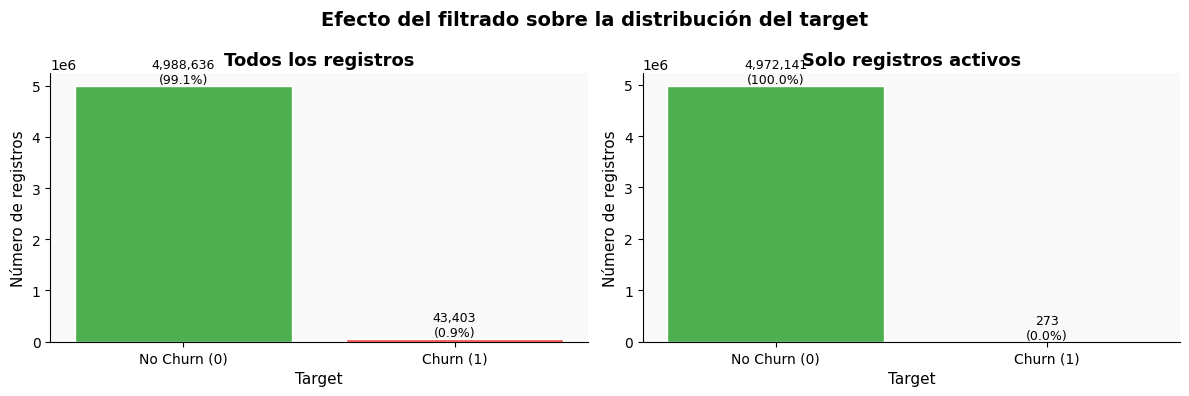

In [19]:
# ──────────────────────────────────────────────────────────────
# FILTRADO: conservar registros con ALGUNA actividad de compra
# Se eliminan los meses donde transacciones Y cajas son ambos <= 0.
# Estos son meses "fantasma" sin información útil para el modelo.
# ──────────────────────────────────────────────────────────────
mask_activos = (
    (data['num_transacciones'] > 0) |
    (data['uni_boxes_sold_m']  > 0)
)
datos_modelo = data[mask_activos].copy()

print(f"Registros originales : {len(data):,}")
print(f"Registros filtrados  : {len(datos_modelo):,}  ({len(datos_modelo)/len(data)*100:.1f}%)")
print(f"Registros eliminados : {len(data) - len(datos_modelo):,}")
print()

# Verificar distribución del target en el subconjunto filtrado
tasa = datos_modelo['target'].mean() * 100
print(f"Tasa de churn en datos de modelo: {tasa:.1f}%")

# Gráfica: distribución del target antes y después del filtro
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, dataset, titulo in [
    (axes[0], data,         'Todos los registros'),
    (axes[1], datos_modelo, 'Solo registros activos'),
]:
    counts = dataset['target'].value_counts()
    ax.bar(
        ['No Churn (0)', 'Churn (1)'],
        counts.values,
        color=[COLOR_NO_CHURN, COLOR_CHURN],
        edgecolor='white',
    )
    ax.set_title(titulo)
    ax.set_ylabel('Número de registros')
    ax.set_xlabel('Target')
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({val/len(dataset)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Efecto del filtrado sobre la distribución del target',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Modelado con CatBoost

In [22]:
# ──────────────────────────────────────────────────────────────
# INSTALACIÓN E IMPORTACIÓN DE DEPENDENCIAS DE MODELADO
# catboost maneja categóricas de forma nativa sin one-hot encoding.
# optuna se usa para búsqueda bayesiana de hiperparámetros.
# ──────────────────────────────────────────────────────────────
# !pip install catboost optuna   # descomentar si no están instalados

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    precision_recall_curve,
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silenciar logs de Optuna


In [23]:
# ──────────────────────────────────────────────────────────────
# PREPARACIÓN DE FEATURES Y TARGET
# Se excluyen columnas no predictivas: IDs, fecha y auxiliares.
# ──────────────────────────────────────────────────────────────
df = datos_modelo.copy()

TARGET       = 'target'
COLS_EXCLUIR = [TARGET, 'customer_id', 'calmonth', 'hist_months',
                'inactive_month']

X = df.drop(columns=[c for c in COLS_EXCLUIR if c in df.columns])
y = df[TARGET]

# Identificar automáticamente las columnas categóricas
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Features totales    : {X.shape[1]}")
print(f"Features categóricas: {len(cat_features)}  → {cat_features}")
print(f"Registros de train  : {len(X):,}")
print(f"Tasa de churn       : {y.mean()*100:.1f}%")


Features totales    : 48
Features categóricas: 3  → ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']
Registros de train  : 4,972,414
Tasa de churn       : 0.0%


### 6a. Entrenamiento base con todas las features

In [24]:
# ──────────────────────────────────────────────────────────────
# SPLIT TRAIN / VALIDACIÓN (80 / 20, estratificado por target)
# Se usa random_state=42 para reproducibilidad.
# Nota: en producción lo ideal es un split temporal (por calmonth).
# ──────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"Train: {len(X_train):,} registros  |  Test: {len(X_test):,} registros")


Train: 3,977,931 registros  |  Test: 994,483 registros


In [25]:
# ──────────────────────────────────────────────────────────────
# MODELO BASE — TODAS LAS FEATURES
# Configuración conservadora para establecer un baseline.
# eval_metric='PRAUC' (área bajo la curva Precision-Recall)
# es más informativa que AUC-ROC cuando las clases están desbalanceadas.
# ──────────────────────────────────────────────────────────────
model_base = CatBoostClassifier(
    iterations          = 100,
    learning_rate       = 0.05,
    depth               = 6,
    loss_function       = 'Logloss',
    eval_metric         = 'PRAUC',
    random_seed         = 42,
    verbose             = 200,         # imprime cada 200 iteraciones
    early_stopping_rounds = 50,
)

model_base.fit(
    X_train, y_train,
    cat_features  = cat_features,
    eval_set      = (X_test, y_test),
    use_best_model= True,
)

# ── Evaluación ────────────────────────────────────────────────
y_proba_base = model_base.predict_proba(X_test)[:, 1]
y_pred_base  = (y_proba_base > 0.46).astype(int)

print(f"\nAUC-ROC (base): {roc_auc_score(y_test, y_proba_base):.4f}")
print("\nReporte de clasificación (threshold = 0.46):")
print(classification_report(y_test, y_pred_base, target_names=['No Churn', 'Churn']))


0:	learn: 0.0002044	test: 0.0002017	best: 0.0002017 (0)	total: 3.96s	remaining: 6m 32s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3085291083
bestIteration = 34

Shrink model to first 35 iterations.

AUC-ROC (base): 0.9998

Reporte de clasificación (threshold = 0.46):
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00    994428
       Churn       0.00      0.00      0.00        55

    accuracy                           1.00    994483
   macro avg       0.50      0.50      0.50    994483
weighted avg       1.00      1.00      1.00    994483



Top 20 features más importantes (modelo base):
                            feature  importance
                  num_transacciones   29.827092
         num_transacciones_ratio_3m   11.533931
                   uni_boxes_sold_m    7.144712
         num_transacciones_ratio_1m    6.955113
          uni_boxes_sold_m_delta_1m    6.240251
           num_transacciones_sum_3m    5.382868
          uni_boxes_sold_m_delta_3m    3.539244
            num_transacciones_lag_2    3.180909
num_transacciones_zscore_current_3m    2.774843
         num_transacciones_delta_1m    2.577702
          uni_boxes_sold_m_ratio_1m    2.488538
                        num_coolers    1.825101
            num_transacciones_lag_1    1.669736
             uni_boxes_sold_m_lag_2    1.587826
            num_transacciones_lag_3    1.514693
          num_transacciones_mean_3m    1.493355
           num_transacciones_std_6m    1.341273
            uni_boxes_sold_m_std_6m    1.187681
           num_transacciones_sum_6m    1.

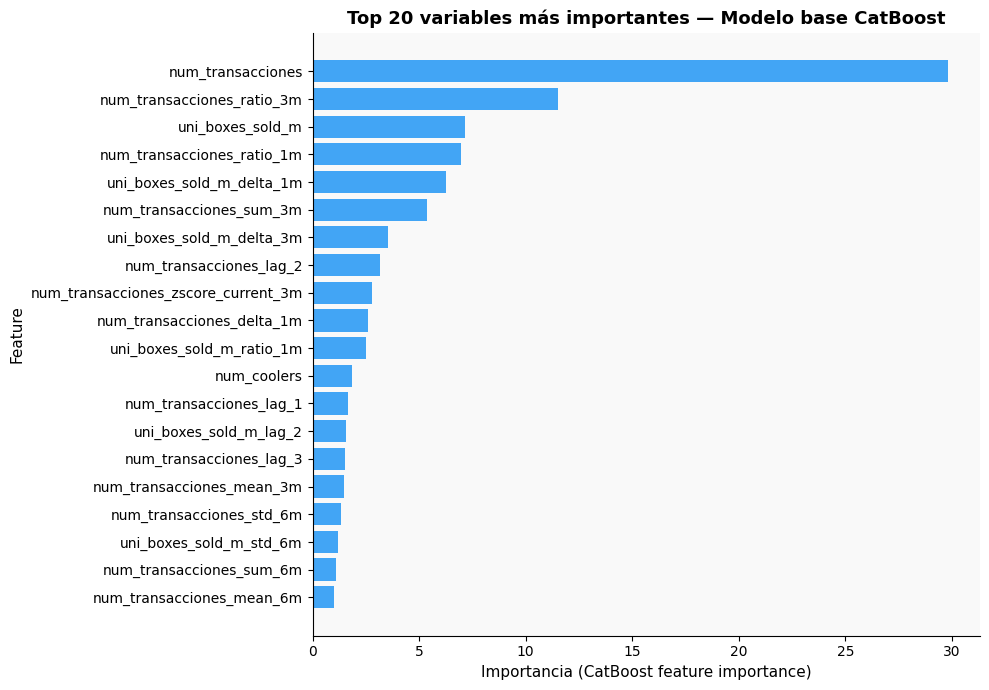

In [26]:
# ──────────────────────────────────────────────────────────────
# IMPORTANCIA DE VARIABLES — MODELO BASE (TOP 20)
# Permite identificar qué features aportan más información
# para seleccionarlas en el modelo final.
# ──────────────────────────────────────────────────────────────
fi_base = (
    pd.DataFrame({
        'feature'   : X.columns,
        'importance': model_base.get_feature_importance(),
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features más importantes (modelo base):")
print(fi_base.head(20).to_string(index=False))

# Gráfica de importancia
fig, ax = plt.subplots(figsize=(10, 7))
top20 = fi_base.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=COLOR_NEUTRAL)
ax.set_title('Top 20 variables más importantes — Modelo base CatBoost')
ax.set_xlabel('Importancia (CatBoost feature importance)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# Guardar lista de top-20 para el modelo reducido
columnas_importantes = fi_base.head(20)['feature'].tolist()


### 6b. Entrenamiento con top-20 features

In [27]:
# ──────────────────────────────────────────────────────────────
# MODELO REDUCIDO — SOLO TOP-20 FEATURES
# Reducir el número de features mejora la interpretabilidad
# y suele generalizar mejor al reducir el ruido.
# ──────────────────────────────────────────────────────────────
X_top = df[columnas_importantes]
y_top = df[TARGET]

cat_features_top = X_top.select_dtypes(include=['object', 'category']).columns.tolist()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_top, y_top,
    test_size=0.2, random_state=42, stratify=y_top
)

model_top20 = CatBoostClassifier(
    iterations          = 300,
    learning_rate       = 0.05,
    depth               = 6,
    loss_function       = 'Logloss',
    eval_metric         = 'PRAUC',
    random_seed         = 42,
    verbose             = 200,
    early_stopping_rounds = 50,
)

model_top20.fit(
    X_tr, y_tr,
    cat_features  = cat_features_top,
    eval_set      = (X_te, y_te),
    use_best_model= True,
)

y_proba_top20 = model_top20.predict_proba(X_te)[:, 1]
y_pred_top20  = (y_proba_top20 > 0.466).astype(int)

print(f"AUC-ROC (top-20): {roc_auc_score(y_te, y_proba_top20):.4f}")
print("\nReporte de clasificación (threshold = 0.466):")
print(classification_report(y_te, y_pred_top20, target_names=['No Churn', 'Churn']))


0:	learn: 0.0004122	test: 0.0001640	best: 0.0001640 (0)	total: 1.78s	remaining: 8m 52s
200:	learn: 0.5799697	test: 0.2206604	best: 0.2209417 (199)	total: 4m 34s	remaining: 2m 15s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2209417299
bestIteration = 199

Shrink model to first 200 iterations.
AUC-ROC (top-20): 0.9998

Reporte de clasificación (threshold = 0.466):
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00    994428
       Churn       0.00      0.00      0.00        55

    accuracy                           1.00    994483
   macro avg       0.50      0.50      0.50    994483
weighted avg       1.00      1.00      1.00    994483



### 6c. Optimización de hiperparámetros con Optuna

In [28]:
# ──────────────────────────────────────────────────────────────
# BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (50 trials)
# Optuna usa búsqueda bayesiana (TPE) para encontrar la
# combinación de hiperparámetros que maximiza el AUC-ROC
# en el conjunto de validación.
# ──────────────────────────────────────────────────────────────

def objective(trial):
    """Función objetivo que entrena un CatBoost con los parámetros
    sugeridos por Optuna y devuelve el AUC-ROC en validación."""
    params = {
        'iterations'         : trial.suggest_int  ('iterations',          100, 400),
        'depth'              : trial.suggest_int  ('depth',                 4,   8),
        'learning_rate'      : trial.suggest_float('learning_rate',      0.01, 0.2, log=True),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg',           1,  10),
        'random_strength'    : trial.suggest_float('random_strength',       0,   2),
        'bagging_temperature': trial.suggest_float('bagging_temperature',   0,   1),
        'loss_function'      : 'Logloss',
        'eval_metric'        : 'PRAUC',
        'verbose'            : 0,
        'random_seed'        : 42,
    }

    m = CatBoostClassifier(**params)
    m.fit(
        X_tr, y_tr,
        cat_features        = cat_features_top,
        eval_set            = (X_te, y_te),
        early_stopping_rounds = 10,
        verbose             = False,
    )
    preds = m.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_te, preds)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Mejor AUC-ROC encontrado : {study.best_value:.4f}")
print(f"Mejores hiperparámetros  :")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")


Mejor AUC-ROC encontrado : 0.9998
Mejores hiperparámetros  :
  iterations               : 393
  depth                    : 8
  learning_rate            : 0.17107400807259351
  l2_leaf_reg              : 3.7897662889624897
  random_strength          : 0.6140193443398354
  bagging_temperature      : 0.9990606074147945


### 6d. Modelo final con hiperparámetros óptimos

In [29]:
# ──────────────────────────────────────────────────────────────
# MODELO FINAL — HIPERPARÁMETROS OBTENIDOS POR OPTUNA
# Se sustituyen los valores por los encontrados en el estudio.
# Si se vuelve a correr Optuna los valores cambiarán; ajustar aquí.
# ──────────────────────────────────────────────────────────────
best = study.best_params   # usar directamente los resultados de Optuna

model = CatBoostClassifier(
    iterations          = best['iterations'],
    learning_rate       = best['learning_rate'],
    depth               = best['depth'],
    l2_leaf_reg         = best['l2_leaf_reg'],
    random_strength     = best['random_strength'],
    bagging_temperature = best['bagging_temperature'],
    loss_function       = 'Logloss',
    eval_metric         = 'PRAUC',
    random_seed         = 42,
    verbose             = 200,
    early_stopping_rounds = 50,
)

model.fit(
    X_tr, y_tr,
    cat_features  = cat_features_top,
    eval_set      = (X_te, y_te),
    use_best_model= True,
)

y_pred_proba = model.predict_proba(X_te)[:, 1]
y_pred       = (y_pred_proba > 0.466).astype(int)

print(f"AUC-ROC (modelo final): {roc_auc_score(y_te, y_pred_proba):.4f}")
print("\nReporte de clasificación (threshold = 0.466):")
print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))


0:	learn: 0.0002228	test: 0.0001487	best: 0.0001487 (0)	total: 1.03s	remaining: 6m 45s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2614962258
bestIteration = 22

Shrink model to first 23 iterations.
AUC-ROC (modelo final): 0.9998

Reporte de clasificación (threshold = 0.466):
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00    994428
       Churn       0.67      0.04      0.07        55

    accuracy                           1.00    994483
   macro avg       0.83      0.52      0.53    994483
weighted avg       1.00      1.00      1.00    994483



## 7. Búsqueda del threshold óptimo

Threshold óptimo (max F1): 0.0972
  Precisión en ese punto : 0.2874
  Recall    en ese punto : 0.4545
  F1-score  en ese punto : 0.3521


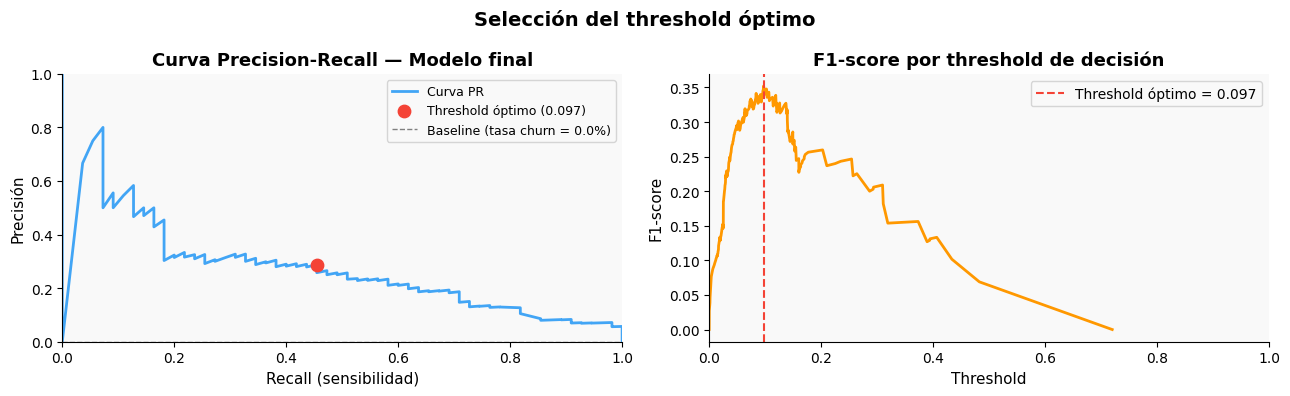

In [30]:
# ──────────────────────────────────────────────────────────────
# CURVA PRECISION-RECALL Y THRESHOLD ÓPTIMO POR F1
# El threshold por defecto (0.5) no es óptimo con clases
# desbalanceadas. Se busca el punto que maximiza el F1-score,
# que balancea precisión y recall simultáneamente.
# ──────────────────────────────────────────────────────────────
precision, recall, thresholds = precision_recall_curve(y_te, y_pred_proba)

# F1 en cada threshold posible
f1_scores      = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx       = np.argmax(f1_scores[:-1])   # último elemento de precision/recall no tiene threshold
best_threshold = thresholds[best_idx]

print(f"Threshold óptimo (max F1): {best_threshold:.4f}")
print(f"  Precisión en ese punto : {precision[best_idx]:.4f}")
print(f"  Recall    en ese punto : {recall[best_idx]:.4f}")
print(f"  F1-score  en ese punto : {f1_scores[best_idx]:.4f}")

# ── Gráfica de la curva Precision-Recall ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: curva PR con el punto óptimo marcado
axes[0].plot(recall, precision, color=COLOR_NEUTRAL, linewidth=2, label='Curva PR')
axes[0].scatter(recall[best_idx], precision[best_idx],
                color=COLOR_CHURN, zorder=5, s=80,
                label=f'Threshold óptimo ({best_threshold:.3f})')
axes[0].axhline(y_te.mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Baseline (tasa churn = {y_te.mean()*100:.1f}%)')
axes[0].set_title('Curva Precision-Recall — Modelo final')
axes[0].set_xlabel('Recall (sensibilidad)')
axes[0].set_ylabel('Precisión')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Panel 2: F1-score por threshold
axes[1].plot(thresholds, f1_scores[:-1], color=COLOR_WARN, linewidth=2)
axes[1].axvline(best_threshold, color=COLOR_CHURN, linestyle='--', linewidth=1.5,
                label=f'Threshold óptimo = {best_threshold:.3f}')
axes[1].set_title('F1-score por threshold de decisión')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-score')
axes[1].legend()
axes[1].set_xlim([0, 1])

plt.suptitle('Selección del threshold óptimo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Importancia de variables — Modelo final

Top 20 features — Modelo final:
                            feature  importance
          uni_boxes_sold_m_delta_1m   19.518464
          num_transacciones_mean_6m   11.939176
num_transacciones_zscore_current_3m    8.009433
           num_transacciones_sum_6m    6.205077
                        num_coolers    6.191912
         num_transacciones_delta_1m    6.058323
            num_transacciones_lag_3    5.951734
           num_transacciones_std_6m    5.233508
                  num_transacciones    4.954525
                   uni_boxes_sold_m    4.458405
            num_transacciones_lag_1    3.742728
             uni_boxes_sold_m_lag_2    3.239292
          uni_boxes_sold_m_delta_3m    3.033956
           num_transacciones_sum_3m    2.707096
            num_transacciones_lag_2    2.635607
         num_transacciones_ratio_1m    2.322466
            uni_boxes_sold_m_std_6m    2.040516
          uni_boxes_sold_m_ratio_1m    0.955353
         num_transacciones_ratio_3m    0.646796
        

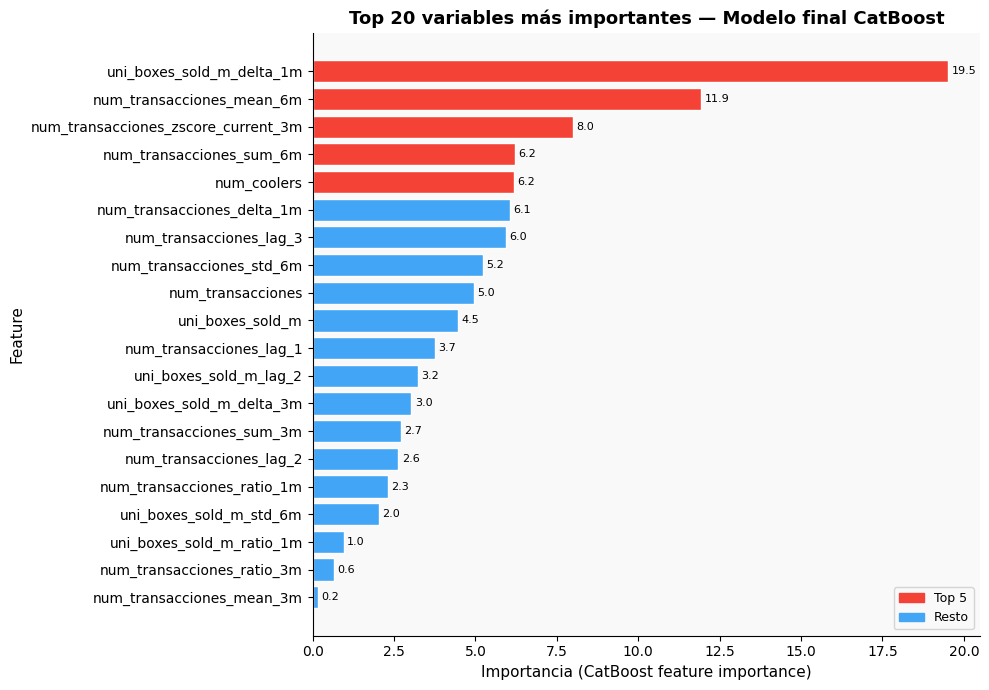

In [31]:
# ──────────────────────────────────────────────────────────────
# IMPORTANCIA DE VARIABLES DEL MODELO FINAL
# Se visualizan las 20 features con mayor contribución
# al poder predictivo del modelo.
# ──────────────────────────────────────────────────────────────
feature_importance = (
    pd.DataFrame({
        'feature'   : X_top.columns,
        'importance': model.get_feature_importance(),
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features — Modelo final:")
print(feature_importance.head(20).to_string(index=False))

# ── Gráfica de barras horizontales ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

top = feature_importance.head(20)
colores = [COLOR_CHURN if i < 5 else COLOR_NEUTRAL for i in range(len(top))]

ax.barh(top['feature'][::-1], top['importance'][::-1],
        color=colores[::-1], edgecolor='white')

ax.set_title('Top 20 variables más importantes — Modelo final CatBoost')
ax.set_xlabel('Importancia (CatBoost feature importance)')
ax.set_ylabel('Feature')

# Etiquetas de valor en cada barra
for bar in ax.patches:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=8)

# Leyenda de colores
from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color=COLOR_CHURN, label='Top 5'),
             Patch(color=COLOR_NEUTRAL, label='Resto')],
    loc='lower right', fontsize=9,
)

plt.tight_layout()
plt.show()


## 9. Persistencia del modelo

In [32]:
# ──────────────────────────────────────────────────────────────
# GUARDAR EL MODELO EN DOS FORMATOS
# .cbm  → formato nativo de CatBoost (recomendado, más eficiente)
# .pkl  → formato genérico de Python (compatible con sklearn pipelines)
# ──────────────────────────────────────────────────────────────

# Formato nativo CatBoost (mejor opción para producción)
model.save_model('catboost_model.cbm')
print("Modelo guardado: catboost_model.cbm")

# Formato pickle (compatible con cualquier pipeline Python)
with open('catboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Modelo guardado: catboost_model.pkl")


Modelo guardado: catboost_model.cbm
Modelo guardado: catboost_model.pkl


In [33]:
# ──────────────────────────────────────────────────────────────
# VERIFICACIÓN DE CARGA DEL MODELO
# Se recarga el modelo para confirmar que el archivo es válido.
# ──────────────────────────────────────────────────────────────
model_loaded = CatBoostClassifier()
model_loaded.load_model('catboost_model.cbm')

# Verificar que las predicciones son idénticas
proba_reload = model_loaded.predict_proba(X_te)[:, 1]
diff_max = np.abs(proba_reload - y_pred_proba).max()
print(f"Diferencia máxima entre predicciones (original vs recargado): {diff_max:.2e}")
print("✓ Modelo recargado correctamente." if diff_max < 1e-6 else "⚠ Hay diferencia en las predicciones.")


Diferencia máxima entre predicciones (original vs recargado): 0.00e+00
✓ Modelo recargado correctamente.


## 10. Predicción sobre datos de test (snapshot)

Para predecir sobre `sales_churn_test.csv` se necesita construir las mismas
features que se usaron en el entrenamiento. La función `build_features` toma
el **snapshot** (último mes por cliente en el test) y el **historial**
(meses previos de train) para calcular lags, medias rodantes y demás features
sin data leakage.


In [10]:
# ──────────────────────────────────────────────────────────────
# FUNCIÓN create_snapshot
# Extrae el último registro por cliente de un DataFrame,
# manteniendo el orden temporal.
# ──────────────────────────────────────────────────────────────
def create_snapshot(df):
    """Devuelve el último registro cronológico de cada cliente."""
    df = df.copy().sort_values(['customer_id', 'calmonth'])
    return df.groupby('customer_id').tail(1).copy()


# Generar snapshot a partir del dataset de train con features
snapshot_train = create_snapshot(df)
snapshot_train.to_csv('snapshot.csv', index=False)

print(f"Snapshot guardado: {snapshot_train.shape[0]:,} clientes × {snapshot_train.shape[1]} columnas")


Snapshot guardado: 241,805 clientes × 5 columnas


In [11]:
# ──────────────────────────────────────────────────────────────
# FUNCIÓN build_features
# Reconstruye todas las features temporales para un snapshot nuevo
# usando el historial de entrenemiento como contexto.
# Pasos:
#   1. Concatenar historial + snapshot y deduplicar.
#   2. Calcular lags, medias, deltas, z-scores y recency.
#   3. Extraer únicamente las filas del snapshot.
#   4. Limpiar tipos de dato para compatibilidad con CatBoost.
# ──────────────────────────────────────────────────────────────
def build_features(snapshot_df, history_df):
    """
    Calcula features temporales para snapshot_df usando history_df
    como contexto histórico. Devuelve un DataFrame con las mismas
    columnas que el set de entrenamiento.
    """
    snap = snapshot_df.copy()
    hist = history_df.copy()

    # Normalizar tipos para evitar errores en el merge
    for frame in [snap, hist]:
        frame['customer_id'] = frame['customer_id'].astype(str)
        frame['calmonth']    = frame['calmonth'].astype(int)

    # Unir historial con snapshot y eliminar duplicados
    full = (
        pd.concat([hist, snap], ignore_index=True)
          .drop_duplicates(subset=['customer_id', 'calmonth'], keep='last')
          .sort_values(['customer_id', 'calmonth'])
          .reset_index(drop=True)
    )

    # ── Lags ──────────────────────────────────────────────────
    full['num_transacciones_lag_1'] = full.groupby('customer_id')['num_transacciones'].shift(1)
    full['uni_boxes_sold_m_lag_1']  = full.groupby('customer_id')['uni_boxes_sold_m'].shift(1)
    full['uni_boxes_sold_m_lag_2']  = full.groupby('customer_id')['uni_boxes_sold_m'].shift(2)

    # ── Deltas ────────────────────────────────────────────────
    full['num_transacciones_delta_1m'] = (
        full['num_transacciones'] - full['num_transacciones_lag_1']
    )
    full['uni_boxes_sold_m_delta_1m'] = (
        full['uni_boxes_sold_m'] - full['uni_boxes_sold_m_lag_1']
    )

    # ── Medias rodantes ───────────────────────────────────────
    for window, suffix in [(3, '3m'), (6, '6m')]:
        full[f'num_transacciones_mean_{suffix}'] = (
            full.groupby('customer_id')['num_transacciones']
                .transform(lambda s: s.rolling(window, min_periods=1).mean())
        )

    # ── Máximo, suma y delta 3m ───────────────────────────────
    full['num_transacciones_max_6m'] = (
        full.groupby('customer_id')['num_transacciones']
            .transform(lambda s: s.rolling(6, min_periods=1).max())
    )
    full['num_transacciones_sum_6m'] = (
        full.groupby('customer_id')['num_transacciones']
            .transform(lambda s: s.rolling(6, min_periods=1).sum())
    )
    full['num_transacciones_delta_3m'] = (
        full['num_transacciones'] -
        full.groupby('customer_id')['num_transacciones'].shift(3)
    )

    # ── Z-scores ──────────────────────────────────────────────
    for var in ['num_transacciones', 'uni_boxes_sold_m']:
        full[f'{var}_zscore_3m'] = (
            full.groupby('customer_id')[var]
                .transform(lambda s: (s - s.rolling(3, min_periods=1).mean()) /
                                     (s.rolling(3, min_periods=1).std().replace(0, np.nan)))
        )

    # ── Ratio de actividad ────────────────────────────────────
    for var in ['num_transacciones', 'uni_boxes_sold_m']:
        full[f'{var}_active_ratio_6m'] = (
            full.groupby('customer_id')[var]
                .transform(lambda s: (s > 0).rolling(6, min_periods=1).mean())
        )

    # ── Recency ───────────────────────────────────────────────
    full['had_purchase']      = (full['num_transacciones'] > 0).astype(int)
    full['last_purchase_month'] = (
        full.groupby('customer_id')
            .apply(lambda g: g['calmonth'].where(g['had_purchase'] == 1).ffill())
            .reset_index(level=0, drop=True)
    )
    full['months_since_last_purchase'] = full.groupby('customer_id').cumcount()

    # ── Extraer solo las filas del snapshot ───────────────────
    keys = snap[['customer_id', 'calmonth']].drop_duplicates()
    result = full.merge(keys, on=['customer_id', 'calmonth'], how='inner')

    # ── Limpiar tipos para CatBoost ───────────────────────────
    CAT_COLS = ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']
    for c in CAT_COLS:
        if c in result.columns:
            result[c] = result[c].fillna('unknown').astype(str)
    for c in result.columns:
        if c not in CAT_COLS + ['customer_id', 'calmonth']:
            result[c] = pd.to_numeric(result[c], errors='coerce')

    return result


In [12]:
# ──────────────────────────────────────────────────────────────
# LISTA DE FEATURES Y FUNCIÓN DE LIMPIEZA PARA INFERENCIA
# Deben coincidir exactamente con las usadas en entrenamiento.
# ──────────────────────────────────────────────────────────────
CAT_COLS = ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']

FEATURES = [
    'months_since_last_purchase',
    'num_transacciones_lag_1',
    'territory_d',
    'num_transacciones_delta_1m',
    'num_coolers',
    'num_doors',
    'rtm_customer_size_d',
    'comercial_subchannel_d',
    'uni_boxes_sold_m_lag_1',
    'uni_boxes_sold_m_delta_1m',
    'num_transacciones_zscore_3m',
    'num_transacciones_mean_6m',
    'num_transacciones_mean_3m',
    'num_transacciones_max_6m',
    'uni_boxes_sold_m_lag_2',
    'uni_boxes_sold_m_active_ratio_6m',
    'num_transacciones_sum_6m',
    'uni_boxes_sold_m_zscore_3m',
    'num_transacciones_delta_3m',
    'num_transacciones_active_ratio_6m',
]


def clean_for_catboost(df, cat_cols):
    """
    Garantiza que las columnas categóricas sean strings y las
    numéricas sean numéricas antes de pasarlas a CatBoost.
    """
    df = df.copy()
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype(str).fillna('unknown')
    for c in df.columns:
        if c not in cat_cols + ['customer_id', 'calmonth']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


In [15]:
# ──────────────────────────────────────────────────────────────
# PREDICCIÓN SOBRE EL CONJUNTO DE TEST
# 1. Se carga el test y se genera el snapshot (último mes/cliente).
# 2. Se construyen las features usando el historial de train.
# 3. Se predicen probabilidades con el modelo final.
# 4. Regla de negocio: clientes activos en el snapshot (trans > 0
#    y cajas > 0) reciben probabilidad = 0 (no son churners inmediatos).
# ──────────────────────────────────────────────────────────────
test = pd.read_csv('Sales_churn_test.csv')

# Merge con coolers y clientes para tener las mismas columnas que train
test = test.merge(coolers,   on=['customer_id', 'calmonth'], how='left')
test = test.merge(clientes,  on='customer_id',               how='left')

# Generar snapshot: último mes registrado por cliente en el test
snapshot_test  = create_snapshot(test)
history_df     = pd.read_csv('snapshot.csv')

# Construir features con contexto histórico
features_test  = build_features(snapshot_test, history_df)

# 🔥 CORRECCIÓN MÁGICA: Usar el orden exacto de columnas que recuerda el modelo entrenado
MODEL_FEATURES = model.feature_names_
X_pred         = features_test[MODEL_FEATURES].copy()

# Limpiar con las columnas del modelo
X_pred         = clean_for_catboost(X_pred, CAT_COLS)

# Crear Pool usando el orden correcto para los índices categóricos
cat_idx  = [MODEL_FEATURES.index(c) for c in CAT_COLS if c in MODEL_FEATURES]
pool_pred = Pool(data=X_pred, cat_features=cat_idx)

# Crear Pool de CatBoost indicando explícitamente las categóricas
cat_idx  = [FEATURES.index(c) for c in CAT_COLS if c in FEATURES]
pool_pred = Pool(data=X_pred, cat_features=cat_idx)

# Predicción de probabilidades y etiquetas
probs = model.predict_proba(pool_pred)[:, 1]
preds = (probs > best_threshold).astype(int)

# Regla de negocio: si el cliente compró en su último mes registrado → no churn
mask_activo = (
    (snapshot_test['num_transacciones'] > 0) &
    (snapshot_test['uni_boxes_sold_m']  > 0)
).values
probs[mask_activo] = np.minimum(probs[mask_activo], 0.01)
preds[mask_activo] = 0

# Agregar resultados al snapshot
snapshot_test['probability'] = probs
snapshot_test['prediction']  = preds

print(f"Clientes predichos   : {len(snapshot_test):,}")
print(f"Predicciones churn=1 : {preds.sum():,} ({preds.mean()*100:.1f}%)")
print(f"Probabilidad media   : {probs.mean():.4f}")
print()
print("Distribución de predicciones:")
print(snapshot_test['prediction'].value_counts().rename({0: 'No Churn (0)', 1: 'Churn (1)'}).to_string())


/var/folders/_x/6m2wdf595bs0dhfyjhr0sbdc0000gn/T/ipykernel_87186/1846942254.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['calmonth'].where(g['had_purchase'] == 1).ffill())


KeyError: "['num_transacciones_ratio_3m', 'num_transacciones_ratio_1m', 'num_transacciones_sum_3m', 'uni_boxes_sold_m_delta_3m', 'num_transacciones_lag_2', 'num_transacciones_zscore_current_3m', 'uni_boxes_sold_m_ratio_1m', 'num_transacciones_lag_3', 'num_transacciones_std_6m', 'uni_boxes_sold_m_std_6m'] not in index"

In [ ]:
# ──────────────────────────────────────────────────────────────
# GRÁFICA DE DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS
# Permite verificar que el modelo no está siendo demasiado
# conservador (todas las prob ≈ 0) ni demasiado agresivo.
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de probabilidades predichas
axes[0].hist(probs, bins=40, color=COLOR_NEUTRAL, edgecolor='white')
axes[0].axvline(best_threshold, color=COLOR_CHURN, linestyle='--', linewidth=1.5,
                label=f'Threshold = {best_threshold:.3f}')
axes[0].set_title('Distribución de probabilidades de churn predichas')
axes[0].set_xlabel('Probabilidad de churn')
axes[0].set_ylabel('Número de clientes')
axes[0].legend()

# Barras de predicción final
conteo = pd.Series(preds).value_counts().sort_index()
axes[1].bar(
    ['No Churn (0)', 'Churn (1)'],
    conteo.values,
    color=[COLOR_NO_CHURN, COLOR_CHURN],
    edgecolor='white',
)
for bar, val in zip(axes[1].patches, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}\n({val/len(preds)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Predicciones finales sobre el conjunto de test')
axes[1].set_ylabel('Número de clientes')
axes[1].set_xlabel('Predicción')

plt.suptitle('Resultados de predicción — Conjunto de test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Guardar resultados
snapshot_test[['customer_id', 'calmonth', 'probability', 'prediction']].to_csv(
    'predicciones_churn.csv', index=False
)
print("\nPredicciones guardadas: predicciones_churn.csv")
